In [9]:
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import scipy
import PIL
import requests

In [3]:
np.random.seed(613)

Plotting Using Seaborn

In [4]:
# load data
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

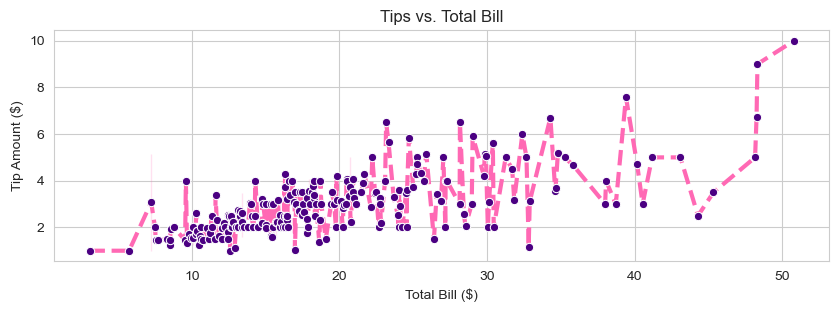

In [11]:
# use premade styles
sns.set_style('whitegrid')
fig = plt.subplots(figsize=(10,3))

# plot data, set to object; adding styling
tipgraph = sns.lineplot(data = tips, # choose dataset
             x = 'total_bill', # define x & y variables
             y = 'tip',
             color = 'hotpink',
             linestyle = '--',
             linewidth = 3,
             marker = 'o',
             markerfacecolor = 'indigo')

# title and label this new obj, tipgraph
tipgraph.set(title = 'Tips vs. Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

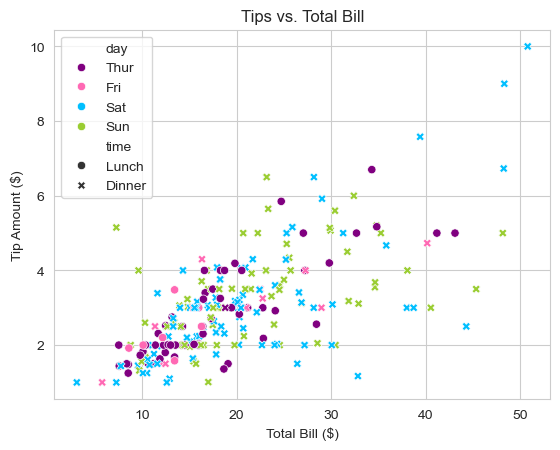

In [14]:
# adding multiple variables
tipgraph = sns.scatterplot(data = tips,
                           x = 'total_bill',
                           y = 'tip',
                           style = 'time', 
                           # markers changing shape and colour depending on day of week and time of day
                           hue = 'day',
                           palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

# title and label this new obj, tipgraph
tipgraph.set(title = 'Tips vs. Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

Pairplot shows the relationship between each variable, highlighted by colour, shows trends per day, etc.

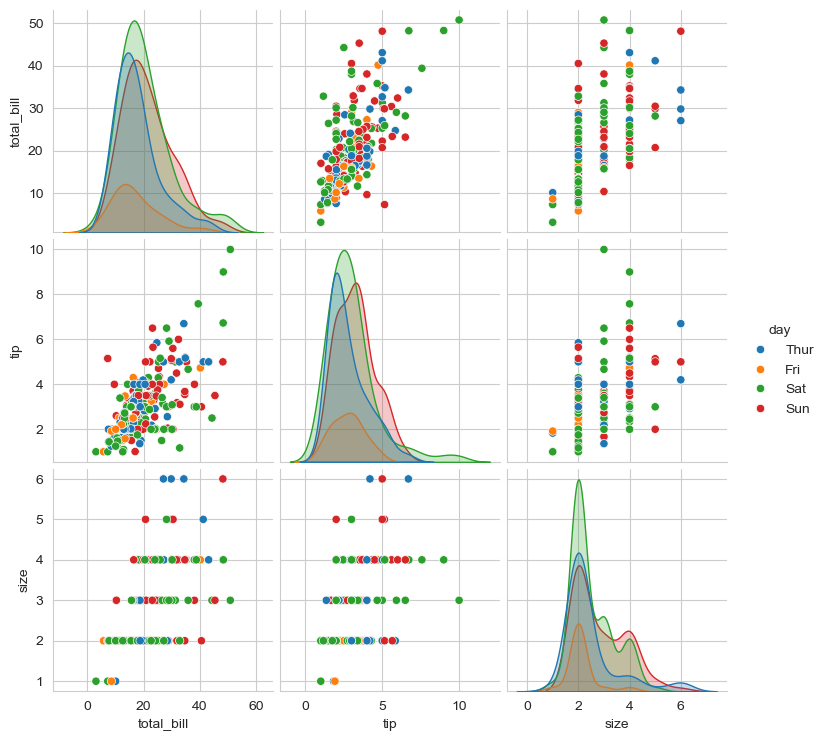

In [16]:
# pairplot - another way to compare variables
sns.pairplot(
    data = tips,
    hue = 'day'
)

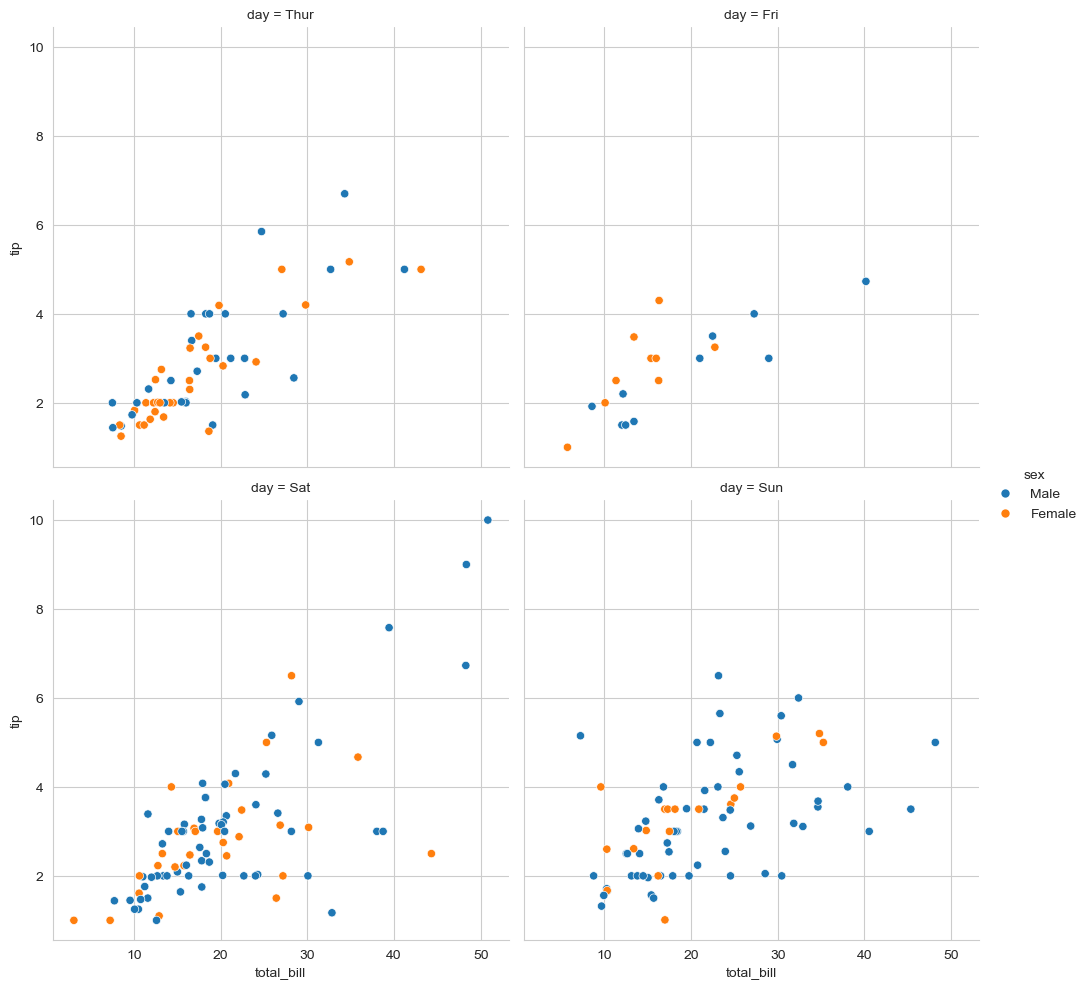

In [18]:
# relplot - explore specific levels within variables
daysplot = sns.relplot(
    data = tips,
    x = 'total_bill',
    y = 'tip',
    hue = 'sex',
    col = 'day',
    kind = 'scatter',
    col_wrap = 2
)
# comparing tips and total bill cost per day, and by gender

Plotting Using Go

In [20]:
import plotly.graph_objects as go # 'go' = 'graph obj'

x1 = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp', 'Sanji'])
y1 = np.array([110, 180, 240, 99, 220])

In [24]:
# making our plot
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1,
                            mode = 'markers',
                            marker = dict(size = 15,
                                          color = 'hotpink',
                                          opacity = 1,
                                          line = dict(width = 5,
                                                      color = 'purple'))))
graph.update_layout(title = 'Pirate Scores',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Score',
                    width = 500,
                    height = 500)
graph.show()

Making Wordclouds

In [29]:
!pip install WordCloud
# from wordcloud import WordCloud

df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", on_bad_lines = 'skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(-0.5, 399.5, 199.5, -0.5)

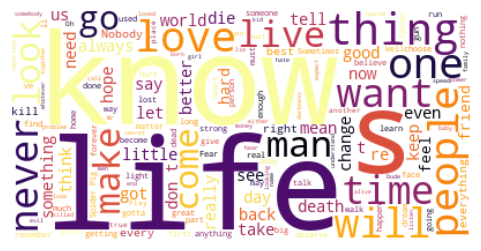

In [ ]:
# generate wordcloud
text = " ".join(each for each in df.quote) # using quotes coloumn in dataset, join text from each row in that col into a string separated by a space

wordcloud = WordCloud(background_color = 'white',
                      colormap = 'inferno').generate(text) # colormaps in pkg, read documenation for other options

fig, ax = plt.subplots(figsize=(7,3)) # create figure
ax.imshow(wordcloud, interpolation = 'bilinear') # add image to plot (the wordcloud) # interp makes it look smoother
ax.axis('off') # turn off tick marks, etc..

Making Venn Diagrams

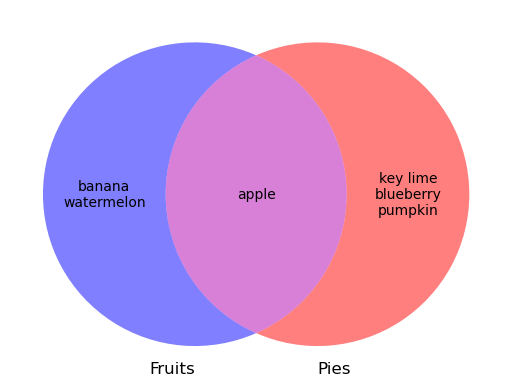

In [ ]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'),
                            set_colors=("blue", "red"),
                            alpha=0.5)


diagram.get_label_by_id("10").set_text("\n".join(A-B)) # in binary, 10 = left circle; show items in A not also in B
diagram.get_label_by_id("11").set_text("\n".join(A&B)) # in binary, 11 = middle overlap between both circles; show items in A and also in B
diagram.get_label_by_id("01").set_text("\n".join(B-A)) # in binary, 01 = right circle; show items in B not also in A